### How are in-demand skills trending for Data Analysts?
**Methology**

1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

### Import Libraries and Data

In [5]:
#libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#loading data
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()
#cleaning
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Group the Skills by Month
Select only those job postings that are for Data Analysts and the job country is the United States. Then extract the month from each job's posting date to see when jobs are listed. Next, converts a column that lists skills into a usable list format. Finally, it rearranges the data so that each skill from the list gets its own row.

In [6]:
## Skill count per month for data analysts
df_DA_US = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

# Explode job_skills column
df_DA_US_exploded = df_DA_US.explode('job_skills')

### Pivot in Prep for Plotting
Create a pivot table from the `df_DA_US_explode`, setting `month` as the index, `job_skills` as the columns, and fills missing entries with zero.

In [8]:
# Group by month and job_skills
df_DA_US_pivot = df_DA_US_exploded.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

df_DA_US_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,assembly,...,vmware,vue,watson,webex,windows,wire,word,workfront,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,12,0,53,0,1,0,0,1,1,8,...,2,0,0,2,10,0,169,0,0,3
2,13,0,34,1,2,0,0,4,2,7,...,0,5,1,1,21,1,128,0,0,2
3,11,0,41,1,3,0,0,6,2,4,...,1,2,0,2,14,3,142,0,0,4
4,5,0,57,1,0,0,0,1,0,1,...,2,0,0,1,24,4,143,1,0,2
5,6,1,35,0,3,0,0,1,2,1,...,0,0,0,1,20,0,92,0,0,1
6,10,3,33,1,1,0,2,0,0,4,...,1,0,0,0,15,2,126,0,0,2
7,13,0,33,0,1,0,0,1,0,4,...,0,0,0,0,15,2,101,0,1,0
8,9,2,29,0,0,0,0,0,0,14,...,0,0,0,1,15,1,112,0,0,5
9,7,0,19,1,0,1,0,2,0,0,...,2,0,0,0,11,0,65,0,0,2


### Sort columns by count and change month numbers to names
Add a new row labeled Total that sums up counts across all months for each skill. Finally, it reorders the columns based on the total counts, displaying them from highest to lowest, and shows the updated pivot table.

In [9]:
# sorts by count
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_US_pivot = df_DA_US_pivot.drop('Total')

df_DA_US_pivot

job_skills,sql,excel,tableau,python,power bi,sas,r,word,powerpoint,oracle,...,mariadb,mxnet,next.js,ringcentral,sqlserver,svelte,theano,tidyr,symphony,yarn
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,1138,781,646,529,326,394,338,169,176,164,...,0,0,0,1,0,0,0,0,0,0
2,782,544,408,378,302,270,233,128,130,99,...,0,0,0,0,0,0,0,0,0,0
3,802,580,463,400,277,300,241,142,127,107,...,0,0,0,0,0,0,0,0,0,0
4,845,577,462,421,292,258,238,143,133,122,...,0,0,0,0,0,0,0,0,0,0
5,706,490,367,336,251,206,219,92,119,98,...,1,0,0,0,0,0,0,0,0,0
6,742,491,395,396,272,202,252,126,116,99,...,0,0,0,0,0,0,0,0,0,0
7,560,431,296,292,190,182,188,101,101,62,...,0,0,1,0,1,0,0,0,0,1
8,784,641,480,460,292,272,321,112,133,98,...,0,0,0,0,0,0,0,0,0,0
9,485,336,277,253,183,150,157,65,53,67,...,0,0,0,0,0,0,0,0,1,0


### Plot the Monthly Skill Counts
Plot a line chart of the top 5 skills for data analysts, indexed by month. It selects the first five columns and plots them.

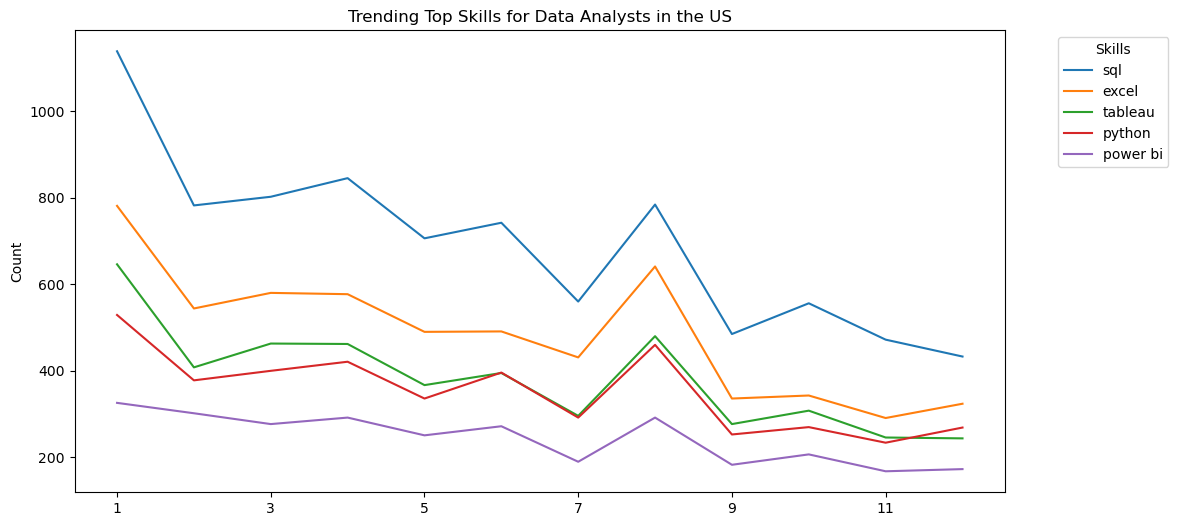

In [10]:
df_DA_US_pivot.iloc[:, :5].plot(kind='line', figsize=(12, 6))

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Count')
plt.xlabel('')
plt.legend(title='Skills', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Calculate Percentage of Total Jobs
Calculates the total number of entries for each month in df_DA by grouping the data by 'month' and counting the number of occurrences in each group, storing the results in DA_totals. This is needed to compute the percentages.

In [30]:
# Get monthly totals
DA_totals = df_DA_US.groupby('job_posted_month_no').size()

DA_totals

job_posted_month_no
1     1816
2     1284
3     1362
4     1369
5     1156
6     1207
7      955
8     1414
9      856
10    1002
11     848
12     817
dtype: int64

This code calculates the percentage of each skill's occurrence for each month by dividing the first 12 rows of the df_DA_pivot DataFrame, which contains skill counts, by the monthly totals in DA_totals and multiplying by 100. The new DataFrame, df_DA_pivot_percent, shows skill distributions as percentages of total monthly job entries.

In [35]:
df_DA_US_percent = df_DA_US_pivot.div(DA_totals/100, axis=0).round(2)

# changes month number to month name
df_DA_US_percent = df_DA_US_percent.reset_index()
df_DA_US_percent['job_posted_month'] = df_DA_US_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month')
df_DA_US_percent = df_DA_US_percent.drop(columns='job_posted_month_no')

df_DA_US_percent

job_skills,sql,excel,tableau,python,power bi,sas,r,word,powerpoint,oracle,...,mariadb,mxnet,next.js,ringcentral,sqlserver,svelte,theano,tidyr,symphony,yarn
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,62.67,43.01,35.57,29.13,17.95,21.70,18.61,9.31,9.69,9.03,...,0.00,0.00,0.0,0.06,0.0,0.00,0.00,0.0,0.00,0.0
Feb,60.90,42.37,31.78,29.44,23.52,21.03,18.15,9.97,10.12,7.71,...,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0
Mar,58.88,42.58,33.99,29.37,20.34,22.03,17.69,10.43,9.32,7.86,...,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0
Apr,61.72,42.15,33.75,30.75,21.33,18.85,17.38,10.45,9.72,8.91,...,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0
May,61.07,42.39,31.75,29.07,21.71,17.82,18.94,7.96,10.29,8.48,...,0.09,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0
Jun,61.47,40.68,32.73,32.81,22.54,16.74,20.88,10.44,9.61,8.20,...,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0
Jul,58.64,45.13,30.99,30.58,19.90,19.06,19.69,10.58,10.58,6.49,...,0.00,0.00,0.1,0.00,0.1,0.00,0.00,0.0,0.00,0.1
Aug,55.45,45.33,33.95,32.53,20.65,19.24,22.70,7.92,9.41,6.93,...,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0
Sep,56.66,39.25,32.36,29.56,21.38,17.52,18.34,7.59,6.19,7.83,...,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.12,0.0


### Plot Monthly Skill Demand
Creates a line plot for the top five skills of data analysts, shown as percentages of the total job entries per month, using the first 5 columns of the `df_DA_pivot_percent` DataFrame. Also the legend is moved outside of the plot for readability.

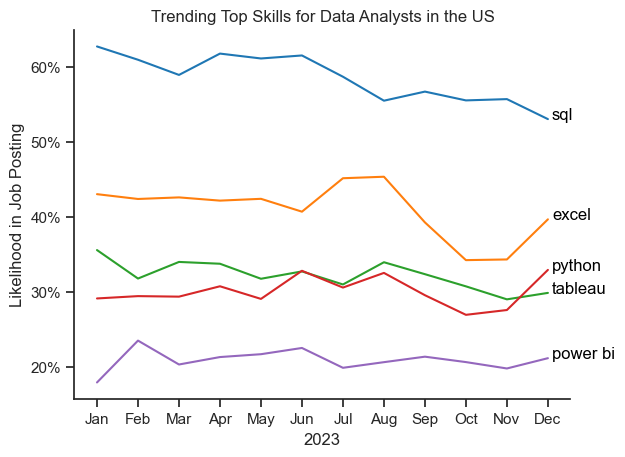

In [66]:
from matplotlib.ticker import PercentFormatter

df_plot = df_DA_US_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() # remove top and right spines

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.1, df_plot.iloc[-1, i], df_plot.columns[i], color='black')

plt.show()